# 01 Data Access and Masks

This notebook is the Colab entry point for the JPCZ catalog project. It clones the GitHub repository into the Colab runtime, installs the project, and loads the initial spatial definitions for the working domain, JPCZ polygon, and vorticity box.

Before running the setup cell below, replace the placeholder `REPO_URL` with your actual GitHub repository URL.

In [14]:
REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"

if "<your-username>" in REPO_URL or "<your-repo>" in REPO_URL:
    raise ValueError("Replace REPO_URL with your actual GitHub repository URL before running this notebook.")


In [15]:
import os
import shutil
import subprocess
import sys

# Always move to a safe directory first.
os.chdir("/content")

if os.path.exists(REPO_DIR):
    print(f"Removing old repo at {REPO_DIR}")
    shutil.rmtree(REPO_DIR)

proc = subprocess.run(
    ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
    text=True,
    capture_output=True,
)

print(proc.stdout)
print(proc.stderr)

if proc.returncode != 0:
    raise RuntimeError(f"git clone failed:\n{proc.stderr}")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
    check=True,
)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
    check=True,
)

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")



Cloning into '/content/JPCZcatalog'...

Working directory: /content/JPCZcatalog


In [16]:
import os
import sys

src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from jpcz_catalog.config import (
    EVENT_FIELD_UNITS,
    EXTENDED_DOMAIN,
    JPCZ_POLYGON_VERTICES,
    VORTICITY_BOX,
    WORKING_DOMAIN,
)

print("Working domain:", WORKING_DOMAIN)
print("Extended domain:", EXTENDED_DOMAIN)
print("Vorticity box:", VORTICITY_BOX)
print("JPCZ polygon vertices:", JPCZ_POLYGON_VERTICES)
print("Field units:", EVENT_FIELD_UNITS)



Working domain: BoundingBox(lon_min=120.0, lon_max=150.0, lat_min=30.0, lat_max=50.0)
Extended domain: BoundingBox(lon_min=120.0, lon_max=160.0, lat_min=30.0, lat_max=50.0)
Vorticity box: BoundingBox(lon_min=127.0, lon_max=140.0, lat_min=37.0, lat_max=45.5)
JPCZ polygon vertices: ((129.5, 41.0), (136.0, 37.4), (134.5, 35.8), (128.8, 38.0))
Field units: {'divergence_925hpa': 's^-1', 'divergence_925hpa_display': '1e-5 s^-1', 'relative_vorticity_925hpa': 's^-1', 'relative_vorticity_925hpa_display': '1e-5 s^-1', 'seoul_minus_sapporo_slp': 'hPa'}


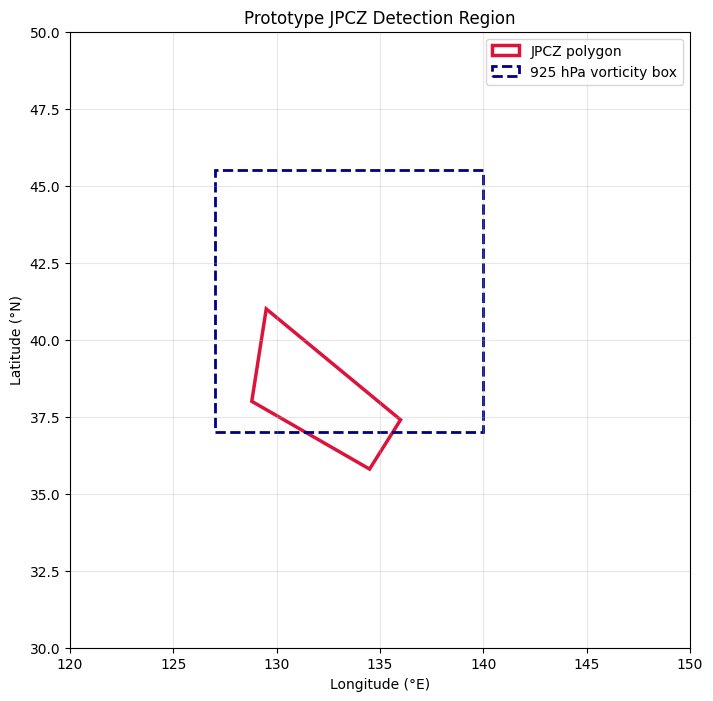

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle

from jpcz_catalog.config import (
    JPCZ_POLYGON_VERTICES,
    VORTICITY_BOX,
    WORKING_DOMAIN,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(WORKING_DOMAIN.lon_min, WORKING_DOMAIN.lon_max)
ax.set_ylim(WORKING_DOMAIN.lat_min, WORKING_DOMAIN.lat_max)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Prototype JPCZ Detection Region")

polygon = Polygon(
    JPCZ_POLYGON_VERTICES,
    closed=True,
    fill=False,
    edgecolor="crimson",
    linewidth=2.5,
    label="JPCZ polygon",
)

vort_box = Rectangle(
    (VORTICITY_BOX.lon_min, VORTICITY_BOX.lat_min),
    VORTICITY_BOX.lon_max - VORTICITY_BOX.lon_min,
    VORTICITY_BOX.lat_max - VORTICITY_BOX.lat_min,
    fill=False,
    edgecolor="navy",
    linestyle="--",
    linewidth=2,
    label="925 hPa vorticity box",
)

ax.add_patch(polygon)
ax.add_patch(vort_box)

ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.show()


In [20]:
%pip install -q cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 79.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


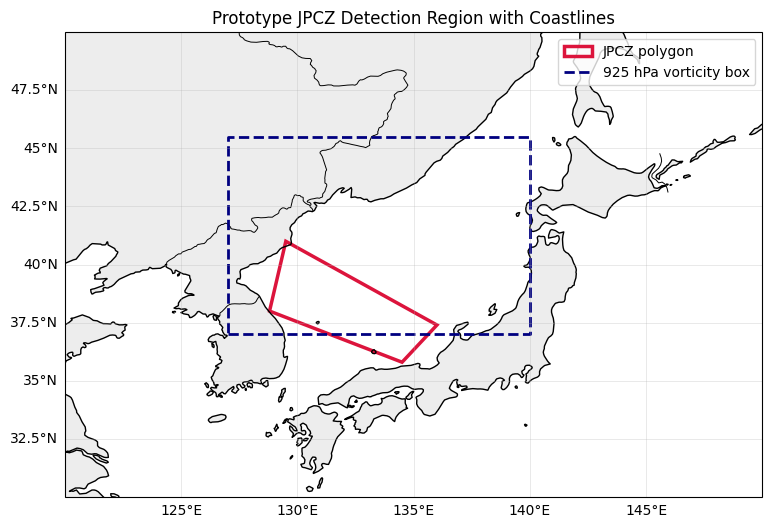

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from jpcz_catalog.config import (
    JPCZ_POLYGON_VERTICES,
    VORTICITY_BOX,
    WORKING_DOMAIN,
)

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [
        WORKING_DOMAIN.lon_min,
        WORKING_DOMAIN.lon_max,
        WORKING_DOMAIN.lat_min,
        WORKING_DOMAIN.lat_max,
    ],
    crs=ccrs.PlateCarree(),
)

ax.coastlines(resolution="50m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=1.0)

polygon = Polygon(
    JPCZ_POLYGON_VERTICES,
    closed=True,
    fill=False,
    edgecolor="crimson",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
    label="JPCZ polygon",
)
ax.add_patch(polygon)

rect_lon = [
    VORTICITY_BOX.lon_min,
    VORTICITY_BOX.lon_max,
    VORTICITY_BOX.lon_max,
    VORTICITY_BOX.lon_min,
    VORTICITY_BOX.lon_min,
]
rect_lat = [
    VORTICITY_BOX.lat_min,
    VORTICITY_BOX.lat_min,
    VORTICITY_BOX.lat_max,
    VORTICITY_BOX.lat_max,
    VORTICITY_BOX.lat_min,
]
ax.plot(
    rect_lon,
    rect_lat,
    linestyle="--",
    color="navy",
    linewidth=2,
    transform=ccrs.PlateCarree(),
    label="925 hPa vorticity box",
)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Prototype JPCZ Detection Region with Coastlines")
ax.legend(loc="upper right")
plt.show()


In [22]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr


In [23]:
import xarray as xr

from jpcz_catalog.config import WORKING_DOMAIN

STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

ds = xr.open_zarr(
    STORE,
    chunks=None,
    storage_options={"token": "anon"},
)

print("valid_time_start:", ds.attrs.get("valid_time_start"))
print("valid_time_stop:", ds.attrs.get("valid_time_stop"))
print("sample variables:", list(ds.data_vars)[:15])

era5_test = ds[
    [
        "u_component_of_wind",
        "v_component_of_wind",
        "mean_sea_level_pressure",
    ]
].sel(
    time=slice("2018-02-02", "2018-02-07T23:00:00"),
    level=925,
    longitude=slice(WORKING_DOMAIN.lon_min, WORKING_DOMAIN.lon_max),
    latitude=slice(WORKING_DOMAIN.lat_max, WORKING_DOMAIN.lat_min),
)

print(era5_test)


valid_time_start: 1940-01-01
valid_time_stop: 2025-12-31
sample variables: ['100m_u_component_of_wind', '100m_v_component_of_wind', '10m_u_component_of_neutral_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind', '10m_v_component_of_wind', '10m_wind_gust_since_previous_post_processing', '2m_dewpoint_temperature', '2m_temperature', 'air_density_over_the_oceans', 'angle_of_sub_gridscale_orography', 'anisotropy_of_sub_gridscale_orography', 'benjamin_feir_index', 'boundary_layer_dissipation', 'boundary_layer_height']
<xarray.Dataset> Size: 17MB
Dimensions:                  (time: 144, latitude: 81, longitude: 121)
Coordinates:
  * time                     (time) datetime64[ns] 1kB 2018-02-02 ... 2018-02...
  * latitude                 (latitude) float32 324B 50.0 49.75 ... 30.25 30.0
  * longitude                (longitude) float32 484B 120.0 120.2 ... 150.0
    level                    int64 8B 925
Data variables:
    u_component_of_wind      (time, latitude, longitude) fl

In [24]:
era5_sample = era5_test.isel(time=slice(0, 2)).load()

print(era5_sample)
print("u units:", era5_sample["u_component_of_wind"].attrs.get("units"))
print("v units:", era5_sample["v_component_of_wind"].attrs.get("units"))
print("msl units:", era5_sample["mean_sea_level_pressure"].attrs.get("units"))


<xarray.Dataset> Size: 236kB
Dimensions:                  (time: 2, latitude: 81, longitude: 121)
Coordinates:
  * time                     (time) datetime64[ns] 16B 2018-02-02 2018-02-02T...
  * latitude                 (latitude) float32 324B 50.0 49.75 ... 30.25 30.0
  * longitude                (longitude) float32 484B 120.0 120.2 ... 150.0
    level                    int64 8B 925
Data variables:
    u_component_of_wind      (time, latitude, longitude) float32 78kB 0.1442 ...
    v_component_of_wind      (time, latitude, longitude) float32 78kB -3.216 ...
    mean_sea_level_pressure  (time, latitude, longitude) float32 78kB 1.04e+0...
Attributes:
    last_updated:           2026-04-20 02:20:40.997455+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-04-14
u units: m s**-1
v units: m s**-1
msl units: Pa


In [25]:
%pip install -q metpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 20.3 MB/s eta 0:00:00


In [26]:
import pandas as pd
import xarray as xr
import metpy.calc as mpcalc
from metpy.units import units

t0 = era5_test.isel(time=0).load()

u = t0["u_component_of_wind"].values * units("m/s")
v = t0["v_component_of_wind"].values * units("m/s")

dx, dy = mpcalc.lat_lon_grid_deltas(
    t0["longitude"].values,
    t0["latitude"].values,
)

div = mpcalc.divergence(u, v, dx=dx, dy=dy)

div_925 = xr.DataArray(
    div.m,
    coords={"latitude": t0.latitude, "longitude": t0.longitude},
    dims=("latitude", "longitude"),
    name="divergence_925hpa",
    attrs={"units": "s^-1", "display_units": "1e-5 s^-1"},
)

div_925_display = div_925 * 1e5
div_925_display.attrs["units"] = "1e-5 s^-1"

print("time:", pd.Timestamp(t0.time.values))
print("min divergence:", float(div_925.min().values), "s^-1")
print("max divergence:", float(div_925.max().values), "s^-1")
print("negative values = convergence")


time: 2018-02-02 00:00:00
min divergence: -0.00023036099267192088 s^-1
max divergence: 0.000184561730495032 s^-1
negative values = convergence


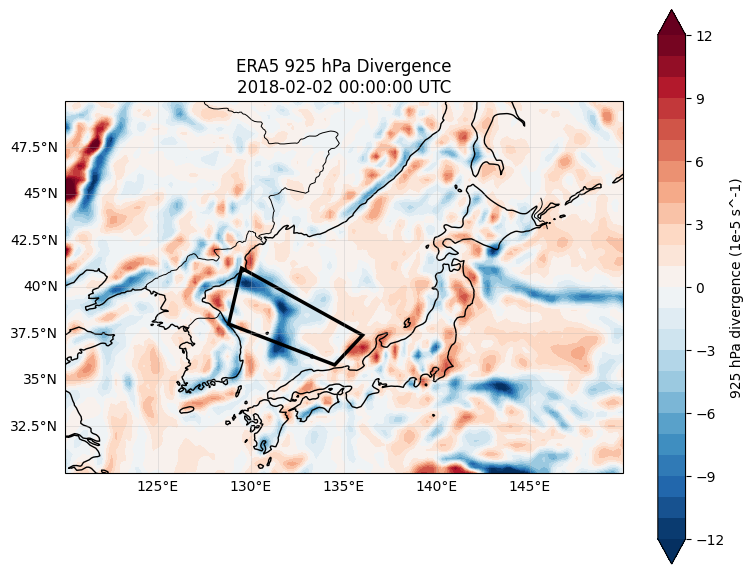

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon

from jpcz_catalog.config import JPCZ_POLYGON_VERTICES, WORKING_DOMAIN

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [
        WORKING_DOMAIN.lon_min,
        WORKING_DOMAIN.lon_max,
        WORKING_DOMAIN.lat_min,
        WORKING_DOMAIN.lat_max,
    ],
    crs=ccrs.PlateCarree(),
)

ax.coastlines(resolution="50m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)

levels = np.arange(-12, 13, 1)
cf = ax.contourf(
    div_925_display.longitude,
    div_925_display.latitude,
    div_925_display,
    levels=levels,
    cmap="RdBu_r",
    extend="both",
    transform=ccrs.PlateCarree(),
)

polygon = Polygon(
    JPCZ_POLYGON_VERTICES,
    closed=True,
    fill=False,
    edgecolor="black",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.add_patch(polygon)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(cf, ax=ax, shrink=0.8)
cbar.set_label("925 hPa divergence (1e-5 s^-1)")

ax.set_title(f"ERA5 925 hPa Divergence\n{pd.Timestamp(t0.time.values)} UTC")
plt.show()


In [28]:
from matplotlib.path import Path
import numpy as np
import pandas as pd
import xarray as xr
import metpy.calc as mpcalc
from metpy.units import units

from jpcz_catalog.config import JPCZ_POLYGON_VERTICES

era5_window = era5_test.load()

dx, dy = mpcalc.lat_lon_grid_deltas(
    era5_window.longitude.values,
    era5_window.latitude.values,
)

divergence_stack = []
for i in range(era5_window.sizes["time"]):
    t_ds = era5_window.isel(time=i)
    u = t_ds["u_component_of_wind"].values * units("m/s")
    v = t_ds["v_component_of_wind"].values * units("m/s")
    div = mpcalc.divergence(u, v, dx=dx, dy=dy).m
    divergence_stack.append(div)

div_925 = xr.DataArray(
    np.stack(divergence_stack, axis=0),
    coords={
        "time": era5_window.time,
        "latitude": era5_window.latitude,
        "longitude": era5_window.longitude,
    },
    dims=("time", "latitude", "longitude"),
    name="divergence_925hpa",
    attrs={"units": "s^-1", "display_units": "1e-5 s^-1"},
)

lon2d, lat2d = np.meshgrid(era5_window.longitude.values, era5_window.latitude.values)
polygon_path = Path(JPCZ_POLYGON_VERTICES)
mask_2d = polygon_path.contains_points(
    np.column_stack([lon2d.ravel(), lat2d.ravel()])
).reshape(lat2d.shape)

polygon_mask = xr.DataArray(
    mask_2d,
    coords={"latitude": era5_window.latitude, "longitude": era5_window.longitude},
    dims=("latitude", "longitude"),
    name="jpcz_polygon_mask",
)

# Area weighting for lat-lon ERA5 grid
weights_2d = xr.DataArray(
    np.cos(np.deg2rad(lat2d)) * mask_2d.astype(float),
    coords={"latitude": era5_window.latitude, "longitude": era5_window.longitude},
    dims=("latitude", "longitude"),
    name="area_weights",
)

polygon_mean_div = (
    (div_925 * weights_2d).sum(dim=("latitude", "longitude"))
    / weights_2d.sum(dim=("latitude", "longitude"))
).rename("polygon_mean_divergence_925hpa")
polygon_mean_div.attrs["units"] = "s^-1"
polygon_mean_div.attrs["display_units"] = "1e-5 s^-1"

D = polygon_mean_div.rolling(time=12, min_periods=12).mean().rename("D_12h")
D.attrs["units"] = "s^-1"
D.attrs["display_units"] = "1e-5 s^-1"

valid_D = D.dropna("time")

print("grid cells inside polygon:", int(mask_2d.sum()))
print("peak hourly convergence:", float(polygon_mean_div.min().values), "s^-1")
print("peak 12-hour mean convergence:", float(valid_D.min().values), "s^-1")
print("time of peak 12-hour mean convergence:", pd.Timestamp(valid_D.idxmin("time").values))


grid cells inside polygon: 277
peak hourly convergence: -3.786095633249372e-05 s^-1
peak 12-hour mean convergence: -3.0843104558537314e-05 s^-1
time of peak 12-hour mean convergence: 2018-02-03 20:00:00


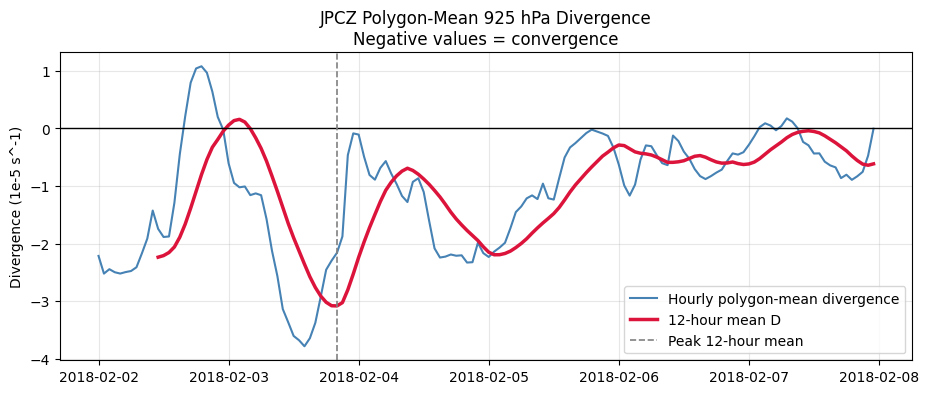

In [29]:
import matplotlib.pyplot as plt

peak_time = pd.Timestamp(valid_D.idxmin("time").values)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    polygon_mean_div.time.values,
    polygon_mean_div.values * 1e5,
    color="steelblue",
    linewidth=1.5,
    label="Hourly polygon-mean divergence",
)

ax.plot(
    valid_D.time.values,
    valid_D.values * 1e5,
    color="crimson",
    linewidth=2.5,
    label="12-hour mean D",
)

ax.axhline(0, color="black", linewidth=1)
ax.axvline(peak_time, color="gray", linestyle="--", linewidth=1.2, label="Peak 12-hour mean")
ax.set_ylabel("Divergence (1e-5 s^-1)")
ax.set_title("JPCZ Polygon-Mean 925 hPa Divergence\nNegative values = convergence")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()


In [30]:
from pathlib import Path
import pandas as pd

peak_time = pd.Timestamp(valid_D.idxmin("time").values)
peak_hourly_time = pd.Timestamp(polygon_mean_div.idxmin("time").values)

summary_text = f"""# February 2018 Baseline Summary

- Target window: 2018-02-02 to 2018-02-07 UTC
- Expected behavior: JPCZ event present with peak convergence on 2018-02-03
- Peak hourly polygon-mean divergence time: {peak_hourly_time}
- Peak 12-hour mean D time: {peak_time}
- Interpretation: negative divergence indicates convergence

This baseline check passed if the strongest convergence signal occurs on 2018-02-03 or is centered on that day.
"""

out_path = Path.cwd() / "outputs" / "verification" / "feb2018_baseline_summary.md"
out_path.write_text(summary_text)

print(summary_text)
print(f"Saved to: {out_path}")


# February 2018 Baseline Summary

- Target window: 2018-02-02 to 2018-02-07 UTC
- Expected behavior: JPCZ event present with peak convergence on 2018-02-03
- Peak hourly polygon-mean divergence time: 2018-02-03 14:00:00
- Peak 12-hour mean D time: 2018-02-03 20:00:00
- Interpretation: negative divergence indicates convergence

This baseline check passed if the strongest convergence signal occurs on 2018-02-03 or is centered on that day.

Saved to: /content/JPCZcatalog/outputs/verification/feb2018_baseline_summary.md


In [31]:
from matplotlib.path import Path as MplPath
import numpy as np
import xarray as xr
import metpy.calc as mpcalc
from metpy.units import units

def compute_polygon_mean_divergence_series(window_ds, polygon_vertices):
    window_ds = window_ds.load()

    dx, dy = mpcalc.lat_lon_grid_deltas(
        window_ds.longitude.values,
        window_ds.latitude.values,
    )

    lon2d, lat2d = np.meshgrid(window_ds.longitude.values, window_ds.latitude.values)
    polygon_path = MplPath(polygon_vertices)
    mask_2d = polygon_path.contains_points(
        np.column_stack([lon2d.ravel(), lat2d.ravel()])
    ).reshape(lat2d.shape)

    weights_2d = np.cos(np.deg2rad(lat2d)) * mask_2d.astype(float)

    polygon_series = []
    for i in range(window_ds.sizes["time"]):
        t_ds = window_ds.isel(time=i)
        u = t_ds["u_component_of_wind"].values * units("m/s")
        v = t_ds["v_component_of_wind"].values * units("m/s")
        div = mpcalc.divergence(u, v, dx=dx, dy=dy).m

        polygon_mean = np.sum(div * weights_2d) / np.sum(weights_2d)
        polygon_series.append(polygon_mean)

    hourly = xr.DataArray(
        np.array(polygon_series),
        coords={"time": window_ds.time},
        dims=("time",),
        name="polygon_mean_divergence_925hpa",
        attrs={"units": "s^-1", "display_units": "1e-5 s^-1"},
    )

    D = hourly.rolling(time=12, min_periods=12).mean().rename("D_12h")
    D.attrs["units"] = "s^-1"
    D.attrs["display_units"] = "1e-5 s^-1"

    return hourly, D, mask_2d


In [32]:
from jpcz_catalog.config import JPCZ_POLYGON_VERTICES, WORKING_DOMAIN
import pandas as pd

dec2018 = ds[
    [
        "u_component_of_wind",
        "v_component_of_wind",
        "mean_sea_level_pressure",
    ]
].sel(
    time=slice("2018-12-01", "2018-12-31T23:00:00"),
    level=925,
    longitude=slice(WORKING_DOMAIN.lon_min, WORKING_DOMAIN.lon_max),
    latitude=slice(WORKING_DOMAIN.lat_max, WORKING_DOMAIN.lat_min),
)

hourly_dec2018, D_dec2018, mask_dec2018 = compute_polygon_mean_divergence_series(
    dec2018,
    JPCZ_POLYGON_VERTICES,
)

valid_D_dec2018 = D_dec2018.dropna("time")

print("December 2018 hourly points:", hourly_dec2018.sizes["time"])
print("December 2018 valid 12-hour windows:", valid_D_dec2018.sizes["time"])
print("Peak December 2018 hourly convergence:", float(hourly_dec2018.min().values), "s^-1")
print("Peak December 2018 12-hour mean convergence:", float(valid_D_dec2018.min().values), "s^-1")
print("Peak December 2018 D time:", pd.Timestamp(valid_D_dec2018.idxmin("time").values))


December 2018 hourly points: 744
December 2018 valid 12-hour windows: 733
Peak December 2018 hourly convergence: -4.3189896868959764e-05 s^-1
Peak December 2018 12-hour mean convergence: -3.6752521130577266e-05 s^-1
Peak December 2018 D time: 2018-12-06 04:00:00


In [33]:
import pandas as pd
import xarray as xr

from jpcz_catalog.config import JPCZ_POLYGON_VERTICES, WORKING_DOMAIN

dec_hourly_series = []
dec_D_series = []

for year in range(2000, 2019):
    dec_ds = ds[
        [
            "u_component_of_wind",
            "v_component_of_wind",
            "mean_sea_level_pressure",
        ]
    ].sel(
        time=slice(f"{year}-12-01", f"{year}-12-31T23:00:00"),
        level=925,
        longitude=slice(WORKING_DOMAIN.lon_min, WORKING_DOMAIN.lon_max),
        latitude=slice(WORKING_DOMAIN.lat_max, WORKING_DOMAIN.lat_min),
    )

    hourly_dec, D_dec, _ = compute_polygon_mean_divergence_series(
        dec_ds,
        JPCZ_POLYGON_VERTICES,
    )

    dec_hourly_series.append(hourly_dec)
    dec_D_series.append(D_dec.dropna("time"))

    print(
        f"{year}: hourly={hourly_dec.sizes['time']}, "
        f"valid_D={D_dec.dropna('time').sizes['time']}, "
        f"peak_D={float(D_dec.dropna('time').min().values):.3e} s^-1"
    )

all_dec_hourly = xr.concat(dec_hourly_series, dim="time").sortby("time")
all_dec_D = xr.concat(dec_D_series, dim="time").sortby("time")

print("Total hourly December points:", all_dec_hourly.sizes["time"])
print("Total valid December D points:", all_dec_D.sizes["time"])


2000: hourly=744, valid_D=733, peak_D=-3.415e-05 s^-1
2001: hourly=744, valid_D=733, peak_D=-3.852e-05 s^-1
2002: hourly=744, valid_D=733, peak_D=-3.087e-05 s^-1
2003: hourly=744, valid_D=733, peak_D=-3.910e-05 s^-1
2004: hourly=744, valid_D=733, peak_D=-2.981e-05 s^-1
2005: hourly=744, valid_D=733, peak_D=-3.846e-05 s^-1
2006: hourly=744, valid_D=733, peak_D=-3.392e-05 s^-1
2007: hourly=744, valid_D=733, peak_D=-4.002e-05 s^-1
2008: hourly=744, valid_D=733, peak_D=-4.106e-05 s^-1
2009: hourly=744, valid_D=733, peak_D=-4.075e-05 s^-1
2010: hourly=744, valid_D=733, peak_D=-3.315e-05 s^-1
2011: hourly=744, valid_D=733, peak_D=-3.036e-05 s^-1
2012: hourly=744, valid_D=733, peak_D=-4.569e-05 s^-1
2013: hourly=744, valid_D=733, peak_D=-3.878e-05 s^-1
2014: hourly=744, valid_D=733, peak_D=-4.362e-05 s^-1
2015: hourly=744, valid_D=733, peak_D=-1.911e-05 s^-1
2016: hourly=744, valid_D=733, peak_D=-3.643e-05 s^-1
2017: hourly=744, valid_D=733, peak_D=-3.686e-05 s^-1
2018: hourly=744, valid_D=73

In [34]:
D_mean = float(all_dec_D.mean().values)
D_std = float(all_dec_D.std().values)
D_threshold = D_mean - 2.0 * D_std

print("December D mean:", D_mean, "s^-1")
print("December D std:", D_std, "s^-1")
print("Shinoda-style threshold:", D_threshold, "s^-1")
print("Display threshold:", D_threshold * 1e5, "1e-5 s^-1")


December D mean: -5.0183133077634934e-06 s^-1
December D std: 1.0336627085534021e-05 s^-1
Shinoda-style threshold: -2.5691567478831536e-05 s^-1
Display threshold: -2.5691567478831536 1e-5 s^-1


In [35]:
import pandas as pd

threshold_hits = (all_dec_D < D_threshold).to_series()

events = []
in_event = False
current_times = []

for timestamp, hit in threshold_hits.items():
    if hit and not in_event:
        in_event = True
        current_times = [timestamp]
    elif hit and in_event:
        current_times.append(timestamp)
    elif (not hit) and in_event:
        event_slice = all_dec_D.sel(time=current_times)
        peak_time = pd.Timestamp(event_slice.idxmin("time").values)
        peak_value = float(event_slice.min().values)

        events.append(
            {
                "event_start": current_times[0],
                "event_end": current_times[-1],
                "event_peak": peak_time,
                "event_peak_D_s-1": peak_value,
                "event_peak_D_1e5_s-1": peak_value * 1e5,
                "duration_hours": len(current_times),
            }
        )
        in_event = False
        current_times = []

if in_event:
    event_slice = all_dec_D.sel(time=current_times)
    peak_time = pd.Timestamp(event_slice.idxmin("time").values)
    peak_value = float(event_slice.min().values)

    events.append(
        {
            "event_start": current_times[0],
            "event_end": current_times[-1],
            "event_peak": peak_time,
            "event_peak_D_s-1": peak_value,
            "event_peak_D_1e5_s-1": peak_value * 1e5,
            "duration_hours": len(current_times),
        }
    )

events_df = pd.DataFrame(events)
print("Detected major December events:", len(events_df))
events_df.head(10)


Detected major December events: 46


,event_start,event_end,event_peak,event_peak_D_s-1,event_peak_D_1e5_s-1,duration_hours
0,2000-12-10 08:00:00,2000-12-11 01:00:00,2000-12-10 16:00:00,-0.000031,-3.092793,18
1,2000-12-25 01:00:00,2000-12-25 13:00:00,2000-12-25 07:00:00,-0.000034,-3.414971,13
2,2001-12-04 22:00:00,2001-12-05 04:00:00,2001-12-05 01:00:00,-0.000029,-2.916595,7
3,2001-12-20 21:00:00,2001-12-21 14:00:00,2001-12-21 06:00:00,-0.000039,-3.851886,18
4,2001-12-23 16:00:00,2001-12-23 21:00:00,2001-12-23 19:00:00,-0.000030,-2.954362,6
5,2002-12-09 15:00:00,2002-12-10 03:00:00,2002-12-09 20:00:00,-0.000030,-3.024454,13
6,2002-12-25 02:00:00,2002-12-25 09:00:00,2002-12-25 05:00:00,-0.000031,-3.087279,8
7,2002-12-31 22:00:00,2002-12-31 23:00:00,2002-12-31 23:00:00,-0.000027,-2.719862,2
8,2003-12-18 14:00:00,2003-12-19 18:00:00,2003-12-18 23:00:00,-0.000039,-3.910486,29
9,2003-12-26 02:00:00,2003-12-26 11:00:00,2003-12-26 07:00:00,-0.000030,-2.952909,10


In [36]:
from pathlib import Path

summary_text = f"""# December Benchmark Summary

- Period: December 2000-2018
- Total detected major events: {len(events_df)}
- Shinoda benchmark: about 35 major December events over 19 years
- First-pass ERA5 result: {len(events_df)}
- Difference from Shinoda benchmark: {len(events_df) - 35}
- December D mean: {D_mean:.6e} s^-1
- December D std: {D_std:.6e} s^-1
- Threshold (mean - 2 std): {D_threshold:.6e} s^-1
- Threshold display units: {D_threshold * 1e5:.3f} 1e-5 s^-1

Interpretation:
This is a functioning first-pass detector. The event count is somewhat higher than Shinoda's benchmark, so spatial-mask refinement and land masking should be tested before finalizing the December reproduction.
"""

out_path = Path.cwd() / "outputs" / "verification" / "december_benchmark_summary.md"
out_path.write_text(summary_text)

print(summary_text)
print(f"Saved to: {out_path}")


# December Benchmark Summary

- Period: December 2000-2018
- Total detected major events: 46
- Shinoda benchmark: about 35 major December events over 19 years
- First-pass ERA5 result: 46
- Difference from Shinoda benchmark: 11
- December D mean: -5.018313e-06 s^-1
- December D std: 1.033663e-05 s^-1
- Threshold (mean - 2 std): -2.569157e-05 s^-1
- Threshold display units: -2.569 1e-5 s^-1

Interpretation:
This is a functioning first-pass detector. The event count is somewhat higher than Shinoda's benchmark, so spatial-mask refinement and land masking should be tested before finalizing the December reproduction.

Saved to: /content/JPCZcatalog/outputs/verification/december_benchmark_summary.md


In [37]:
events_df["year"] = pd.to_datetime(events_df["event_peak"]).dt.year
events_df["date"] = pd.to_datetime(events_df["event_peak"])

print(events_df[["event_peak", "event_peak_D_1e5_s-1", "duration_hours"]].head(15))
print()
print(events_df["year"].value_counts().sort_index())


            event_peak  event_peak_D_1e5_s-1  duration_hours
0  2000-12-10 16:00:00             -3.092793              18
1  2000-12-25 07:00:00             -3.414971              13
2  2001-12-05 01:00:00             -2.916595               7
3  2001-12-21 06:00:00             -3.851886              18
4  2001-12-23 19:00:00             -2.954362               6
5  2002-12-09 20:00:00             -3.024454              13
6  2002-12-25 05:00:00             -3.087279               8
7  2002-12-31 23:00:00             -2.719862               2
8  2003-12-18 23:00:00             -3.910486              29
9  2003-12-26 07:00:00             -2.952909              10
10 2004-12-26 19:00:00             -2.681189               4
11 2004-12-29 01:00:00             -2.981425               9
12 2004-12-31 06:00:00             -2.773208               6
13 2005-12-04 05:00:00             -3.845511              12
14 2005-12-07 12:00:00             -2.956126              17

year
2000    2
2001    

In [38]:
events_df = events_df.sort_values("event_start").reset_index(drop=True)

events_df["next_event_start"] = events_df["event_start"].shift(-1)
events_df["gap_hours_to_next"] = (
    pd.to_datetime(events_df["next_event_start"]) - pd.to_datetime(events_df["event_end"])
).dt.total_seconds() / 3600.0

print(events_df[[
    "event_start",
    "event_end",
    "event_peak",
    "duration_hours",
    "gap_hours_to_next"
]].head(20))

print()
print("Events separated by <= 6 hours:", (events_df["gap_hours_to_next"] <= 6).sum())
print("Events separated by <= 12 hours:", (events_df["gap_hours_to_next"] <= 12).sum())
print("Events separated by <= 24 hours:", (events_df["gap_hours_to_next"] <= 24).sum())


           event_start           event_end          event_peak  \
0  2000-12-10 08:00:00 2000-12-11 01:00:00 2000-12-10 16:00:00   
1  2000-12-25 01:00:00 2000-12-25 13:00:00 2000-12-25 07:00:00   
2  2001-12-04 22:00:00 2001-12-05 04:00:00 2001-12-05 01:00:00   
3  2001-12-20 21:00:00 2001-12-21 14:00:00 2001-12-21 06:00:00   
4  2001-12-23 16:00:00 2001-12-23 21:00:00 2001-12-23 19:00:00   
5  2002-12-09 15:00:00 2002-12-10 03:00:00 2002-12-09 20:00:00   
6  2002-12-25 02:00:00 2002-12-25 09:00:00 2002-12-25 05:00:00   
7  2002-12-31 22:00:00 2002-12-31 23:00:00 2002-12-31 23:00:00   
8  2003-12-18 14:00:00 2003-12-19 18:00:00 2003-12-18 23:00:00   
9  2003-12-26 02:00:00 2003-12-26 11:00:00 2003-12-26 07:00:00   
10 2004-12-26 18:00:00 2004-12-26 21:00:00 2004-12-26 19:00:00   
11 2004-12-28 20:00:00 2004-12-29 04:00:00 2004-12-29 01:00:00   
12 2004-12-31 04:00:00 2004-12-31 09:00:00 2004-12-31 06:00:00   
13 2005-12-04 01:00:00 2005-12-04 12:00:00 2005-12-04 05:00:00   
14 2005-12

In [39]:
from pathlib import Path

events_out = Path.cwd() / "outputs" / "verification" / "december_events_first_pass.csv"
events_df.to_csv(events_out, index=False)

print(f"Saved first-pass events to: {events_out}")


Saved first-pass events to: /content/JPCZcatalog/outputs/verification/december_events_first_pass.csv


In [40]:
import numpy as np
import regionmask
from matplotlib.path import Path as MplPath

from jpcz_catalog.config import JPCZ_POLYGON_VERTICES

# Build the polygon mask on the ERA5 grid already in memory.
lon2d, lat2d = np.meshgrid(era5_test.longitude.values, era5_test.latitude.values)
polygon_path = MplPath(JPCZ_POLYGON_VERTICES)
polygon_mask_2d = polygon_path.contains_points(
    np.column_stack([lon2d.ravel(), lat2d.ravel()])
).reshape(lat2d.shape)

# Regionmask API differs slightly by version, so use a fallback.
defined = regionmask.defined_regions
if hasattr(defined, "natural_earth_v5_0_0"):
    ne = defined.natural_earth_v5_0_0
elif hasattr(defined, "natural_earth_v4_1_0"):
    ne = defined.natural_earth_v4_1_0
else:
    raise RuntimeError("Could not find a supported Natural Earth land mask in regionmask.")

land_regions = getattr(ne, "land_50", getattr(ne, "land_110"))
land_mask = land_regions.mask(era5_test.longitude, era5_test.latitude)

# regionmask returns NaN over ocean and a region id over land.
ocean_mask_2d = np.isnan(land_mask.values)
polygon_ocean_mask_2d = polygon_mask_2d & ocean_mask_2d
polygon_land_mask_2d = polygon_mask_2d & (~ocean_mask_2d)

print("Polygon cells total:", int(polygon_mask_2d.sum()))
print("Polygon ocean cells:", int(polygon_ocean_mask_2d.sum()))
print("Polygon land cells:", int(polygon_land_mask_2d.sum()))


/tmp/ipykernel_15291/605025627.py:23: UserWarning: `land_50` of `natural_earth_v4_1_0` and `natural_earth_v5_0_0` does not quite extend to 90°S - it's recommended to use `natural_earth_v5_1_2` instead. See https://github.com/regionmask/regionmask/issues/487
  land_regions = getattr(ne, "land_50", getattr(ne, "land_110"))


Polygon cells total: 277
Polygon ocean cells: 276
Polygon land cells: 1


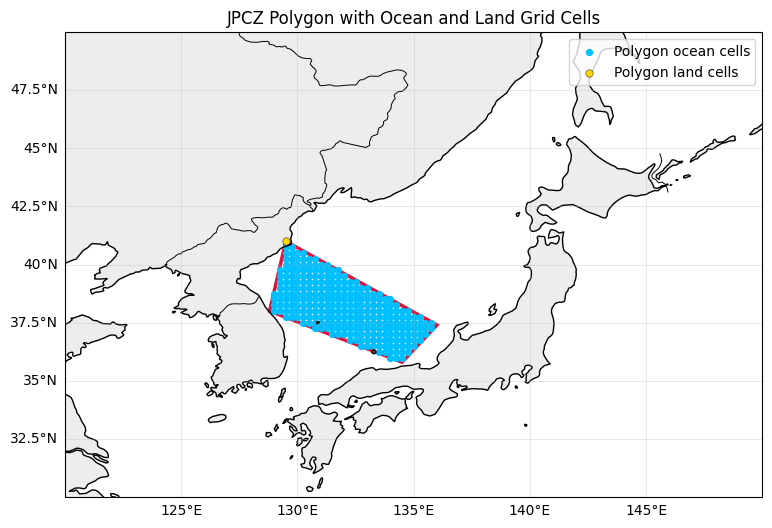

In [41]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon

from jpcz_catalog.config import WORKING_DOMAIN

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [
        WORKING_DOMAIN.lon_min,
        WORKING_DOMAIN.lon_max,
        WORKING_DOMAIN.lat_min,
        WORKING_DOMAIN.lat_max,
    ],
    crs=ccrs.PlateCarree(),
)

ax.coastlines(resolution="50m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)

poly = Polygon(
    JPCZ_POLYGON_VERTICES,
    closed=True,
    fill=False,
    edgecolor="crimson",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
)
ax.add_patch(poly)

ax.scatter(
    lon2d[polygon_ocean_mask_2d],
    lat2d[polygon_ocean_mask_2d],
    s=18,
    color="deepskyblue",
    transform=ccrs.PlateCarree(),
    label="Polygon ocean cells",
)

ax.scatter(
    lon2d[polygon_land_mask_2d],
    lat2d[polygon_land_mask_2d],
    s=28,
    color="gold",
    edgecolor="black",
    linewidth=0.3,
    transform=ccrs.PlateCarree(),
    label="Polygon land cells",
)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title("JPCZ Polygon with Ocean and Land Grid Cells")
ax.legend(loc="upper right")
plt.show()


In [42]:
def count_events_from_threshold(D_series, threshold):
    threshold_hits = (D_series < threshold).to_series()

    events = []
    in_event = False
    current_times = []

    for timestamp, hit in threshold_hits.items():
        if hit and not in_event:
            in_event = True
            current_times = [timestamp]
        elif hit and in_event:
            current_times.append(timestamp)
        elif (not hit) and in_event:
            event_slice = D_series.sel(time=current_times)
            peak_time = pd.Timestamp(event_slice.idxmin("time").values)
            peak_value = float(event_slice.min().values)

            events.append(
                {
                    "event_start": current_times[0],
                    "event_end": current_times[-1],
                    "event_peak": peak_time,
                    "event_peak_D_s-1": peak_value,
                    "event_peak_D_1e5_s-1": peak_value * 1e5,
                    "duration_hours": len(current_times),
                }
            )
            in_event = False
            current_times = []

    if in_event:
        event_slice = D_series.sel(time=current_times)
        peak_time = pd.Timestamp(event_slice.idxmin("time").values)
        peak_value = float(event_slice.min().values)

        events.append(
            {
                "event_start": current_times[0],
                "event_end": current_times[-1],
                "event_peak": peak_time,
                "event_peak_D_s-1": peak_value,
                "event_peak_D_1e5_s-1": peak_value * 1e5,
                "duration_hours": len(current_times),
            }
        )

    return pd.DataFrame(events)


In [43]:
threshold_tests = {
    "mean - 2.0 std": D_mean - 2.0 * D_std,
    "mean - 2.1 std": D_mean - 2.1 * D_std,
    "mean - 2.2 std": D_mean - 2.2 * D_std,
    "mean - 2.3 std": D_mean - 2.3 * D_std,
    "mean - 2.4 std": D_mean - 2.4 * D_std,
    "mean - 2.5 std": D_mean - 2.5 * D_std,
}

for label, threshold in threshold_tests.items():
    test_events = count_events_from_threshold(all_dec_D, threshold)
    print(
        f"{label}: threshold={threshold * 1e5:.3f} (1e-5 s^-1), "
        f"events={len(test_events)}"
    )


mean - 2.0 std: threshold=-2.569 (1e-5 s^-1), events=46
mean - 2.1 std: threshold=-2.673 (1e-5 s^-1), events=44
mean - 2.2 std: threshold=-2.776 (1e-5 s^-1), events=39
mean - 2.3 std: threshold=-2.879 (1e-5 s^-1), events=38
mean - 2.4 std: threshold=-2.983 (1e-5 s^-1), events=30
mean - 2.5 std: threshold=-3.086 (1e-5 s^-1), events=25


In [44]:
from pathlib import Path

sensitivity_text = """# December Threshold Sensitivity

- mean - 2.0 std: 46 events
- mean - 2.1 std: 44 events
- mean - 2.2 std: 39 events
- mean - 2.3 std: 38 events
- mean - 2.4 std: 30 events
- mean - 2.5 std: 25 events

Interpretation:
The first-pass ERA5 detector is sensitive near the event threshold. The difference between the ERA5 result and the Shinoda benchmark appears to be driven mainly by marginal near-threshold events rather than by land contamination or aggressive event splitting.
"""

out_path = Path.cwd() / "outputs" / "verification" / "december_threshold_sensitivity.md"
out_path.write_text(sensitivity_text)

print(sensitivity_text)
print(f"Saved to: {out_path}")


# December Threshold Sensitivity

- mean - 2.0 std: 46 events
- mean - 2.1 std: 44 events
- mean - 2.2 std: 39 events
- mean - 2.3 std: 38 events
- mean - 2.4 std: 30 events
- mean - 2.5 std: 25 events

Interpretation:
The first-pass ERA5 detector is sensitive near the event threshold. The difference between the ERA5 result and the Shinoda benchmark appears to be driven mainly by marginal near-threshold events rather than by land contamination or aggressive event splitting.

Saved to: /content/JPCZcatalog/outputs/verification/december_threshold_sensitivity.md


In [45]:
shinoda_rate = 35 / 19
our_rate = len(events_df) / 19

print("Shinoda monthly event rate:", shinoda_rate)
print("First-pass ERA5 monthly event rate:", our_rate)
print("Difference:", our_rate - shinoda_rate)


Shinoda monthly event rate: 1.8421052631578947
First-pass ERA5 monthly event rate: 2.4210526315789473
Difference: 0.5789473684210527


In [46]:
from pathlib import Path

events_out = Path.cwd() / "outputs" / "verification" / "december_events_first_pass.csv"
events_df.to_csv(events_out, index=False)

print(f"Saved first-pass events to: {events_out}")


Saved first-pass events to: /content/JPCZcatalog/outputs/verification/december_events_first_pass.csv


In [47]:
import numpy as np
import pandas as pd
import xarray as xr
import metpy.calc as mpcalc
from metpy.units import units

# Reference city locations
SEOUL_LAT, SEOUL_LON = 37.5665, 126.9780
SAPPORO_LAT, SAPPORO_LON = 43.0618, 141.3545

def nearest_point(da, lat, lon):
    return da.sel(latitude=lat, longitude=lon, method="nearest")

def compute_vorticity_box_mean_at_time(ds_time):
    u = ds_time["u_component_of_wind"].values * units("m/s")
    v = ds_time["v_component_of_wind"].values * units("m/s")

    dx, dy = mpcalc.lat_lon_grid_deltas(
        ds_time.longitude.values,
        ds_time.latitude.values,
    )

    zeta = mpcalc.vorticity(u, v, dx=dx, dy=dy).m

    zeta_da = xr.DataArray(
        zeta,
        coords={"latitude": ds_time.latitude, "longitude": ds_time.longitude},
        dims=("latitude", "longitude"),
    )

    zeta_box = zeta_da.sel(
        longitude=slice(VORTICITY_BOX.lon_min, VORTICITY_BOX.lon_max),
        latitude=slice(VORTICITY_BOX.lat_max, VORTICITY_BOX.lat_min),
    )

    lat2d, lon2d = np.meshgrid(
        zeta_box.latitude.values,
        zeta_box.longitude.values,
        indexing="ij",
    )
    weights = np.cos(np.deg2rad(lat2d))

    return float((zeta_box.values * weights).sum() / weights.sum())


In [48]:
classified_events = events_df.copy()
classified_events["event_peak"] = pd.to_datetime(classified_events["event_peak"])

slp_diff_values = []
zeta_values = []

for peak_time in classified_events["event_peak"]:
    start_time = peak_time - pd.Timedelta(hours=11)
    end_time = peak_time

    event_window = ds[
        [
            "u_component_of_wind",
            "v_component_of_wind",
            "mean_sea_level_pressure",
        ]
    ].sel(
        time=slice(start_time, end_time),
        level=925,
        longitude=slice(WORKING_DOMAIN.lon_min, WORKING_DOMAIN.lon_max),
        latitude=slice(WORKING_DOMAIN.lat_max, WORKING_DOMAIN.lat_min),
    ).load()

    msl_12h = event_window["mean_sea_level_pressure"].mean("time")
    seoul_msl = float(nearest_point(msl_12h, SEOUL_LAT, SEOUL_LON).values) / 100.0
    sapporo_msl = float(nearest_point(msl_12h, SAPPORO_LAT, SAPPORO_LON).values) / 100.0
    slp_diff = seoul_msl - sapporo_msl
    slp_diff_values.append(slp_diff)

    uv_12h = event_window[["u_component_of_wind", "v_component_of_wind"]].mean("time")
    zeta_mean = compute_vorticity_box_mean_at_time(uv_12h)
    zeta_values.append(zeta_mean)

classified_events["slp_diff_hpa"] = slp_diff_values
classified_events["zeta_box_mean_s-1"] = zeta_values

print(classified_events[[
    "event_peak",
    "event_peak_D_1e5_s-1",
    "slp_diff_hpa",
    "zeta_box_mean_s-1"
]].head())


           event_peak  event_peak_D_1e5_s-1  slp_diff_hpa  zeta_box_mean_s-1
0 2000-12-10 16:00:00             -3.092793     18.786250          -0.000006
1 2000-12-25 07:00:00             -3.414971     16.183125           0.000005
2 2001-12-05 01:00:00             -2.916595      4.894531          -0.000011
3 2001-12-21 06:00:00             -3.851886      1.795859           0.000008
4 2001-12-23 19:00:00             -2.954362      4.339687           0.000002


In [49]:
slp_split = classified_events["slp_diff_hpa"].mean()
zeta_split = (
    classified_events["zeta_box_mean_s-1"].mean()
    + classified_events["zeta_box_mean_s-1"].std()
)

classified_events["monsoon_type"] = np.where(
    classified_events["slp_diff_hpa"] > slp_split,
    "Type 1 strong-monsoon",
    "Type 2 weak-monsoon",
)

classified_events["vorticity_type"] = np.where(
    classified_events["zeta_box_mean_s-1"] > zeta_split,
    "Type 1B higher-vorticity",
    "Type 1A lower-vorticity",
)

print("SLP split:", slp_split, "hPa")
print("Zeta split:", zeta_split, "s^-1")
print()
print(classified_events["monsoon_type"].value_counts())
print()
print(classified_events["vorticity_type"].value_counts())


SLP split: 11.10259850543478 hPa
Zeta split: 1.3482408364617325e-05 s^-1

monsoon_type
Type 1 strong-monsoon    23
Type 2 weak-monsoon      23
Name: count, dtype: int64

vorticity_type
Type 1A lower-vorticity     39
Type 1B higher-vorticity     7
Name: count, dtype: int64


In [50]:
from pathlib import Path

classified_out = Path.cwd() / "outputs" / "verification" / "december_events_classified_first_pass.csv"
classified_events.to_csv(classified_out, index=False)

print(f"Saved classified events to: {classified_out}")


Saved classified events to: /content/JPCZcatalog/outputs/verification/december_events_classified_first_pass.csv


In [51]:
print(classified_events[[
    "event_peak",
    "event_peak_D_1e5_s-1",
    "slp_diff_hpa",
    "zeta_box_mean_s-1",
    "monsoon_type",
    "vorticity_type",
]].head(15))


            event_peak  event_peak_D_1e5_s-1  slp_diff_hpa  zeta_box_mean_s-1  \
0  2000-12-10 16:00:00             -3.092793     18.786250      -6.470472e-06   
1  2000-12-25 07:00:00             -3.414971     16.183125       5.407334e-06   
2  2001-12-05 01:00:00             -2.916595      4.894531      -1.108622e-05   
3  2001-12-21 06:00:00             -3.851886      1.795859       7.547962e-06   
4  2001-12-23 19:00:00             -2.954362      4.339687       1.958588e-06   
5  2002-12-09 20:00:00             -3.024454     12.926719      -3.525693e-06   
6  2002-12-25 05:00:00             -3.087279      6.186172      -2.076181e-07   
7  2002-12-31 23:00:00             -2.719862      6.581406      -6.123474e-06   
8  2003-12-18 23:00:00             -3.910486     18.860625       8.839738e-06   
9  2003-12-26 07:00:00             -2.952909     21.639063      -4.651899e-06   
10 2004-12-26 19:00:00             -2.681189     14.699219      -5.718680e-06   
11 2004-12-29 01:00:00      

In [52]:
print("Monsoon type counts:")
print(classified_events["monsoon_type"].value_counts())
print()
print("Vorticity type counts:")
print(classified_events["vorticity_type"].value_counts())
print()
print("Cross-tab:")
print(pd.crosstab(classified_events["monsoon_type"], classified_events["vorticity_type"]))


Monsoon type counts:
monsoon_type
Type 1 strong-monsoon    23
Type 2 weak-monsoon      23
Name: count, dtype: int64

Vorticity type counts:
vorticity_type
Type 1A lower-vorticity     39
Type 1B higher-vorticity     7
Name: count, dtype: int64

Cross-tab:
vorticity_type         Type 1A lower-vorticity  Type 1B higher-vorticity
monsoon_type                                                            
Type 1 strong-monsoon                       21                         2
Type 2 weak-monsoon                         18                         5


In [53]:
from pathlib import Path

monsoon_counts = classified_events["monsoon_type"].value_counts()
vorticity_counts = classified_events["vorticity_type"].value_counts()
cross_tab = pd.crosstab(classified_events["monsoon_type"], classified_events["vorticity_type"])

summary_text = f"""# December Event Classification Summary

- Total first-pass December events: {len(classified_events)}

## Monsoon types
{monsoon_counts.to_string()}

## Vorticity types
{vorticity_counts.to_string()}

## Cross-tab
{cross_tab.to_string()}

Interpretation:
This is a first-pass ERA5 classification using the Shinoda-style December event detector and clearer label names.
"""

out_path = Path.cwd() / "outputs" / "verification" / "december_classification_summary.md"
out_path.write_text(summary_text)

print(summary_text)
print(f"Saved to: {out_path}")


# December Event Classification Summary

- Total first-pass December events: 46

## Monsoon types
monsoon_type
Type 1 strong-monsoon    23
Type 2 weak-monsoon      23

## Vorticity types
vorticity_type
Type 1A lower-vorticity     39
Type 1B higher-vorticity     7

## Cross-tab
vorticity_type         Type 1A lower-vorticity  Type 1B higher-vorticity
monsoon_type                                                            
Type 1 strong-monsoon                       21                         2
Type 2 weak-monsoon                         18                         5

Interpretation:
This is a first-pass ERA5 classification using the Shinoda-style December event detector and clearer label names.

Saved to: /content/JPCZcatalog/outputs/verification/december_classification_summary.md


In [54]:
type1_mask = classified_events["monsoon_type"] == "Type 1 strong-monsoon"

zeta_split_type1 = (
    classified_events.loc[type1_mask, "zeta_box_mean_s-1"].mean()
    + classified_events.loc[type1_mask, "zeta_box_mean_s-1"].std()
)

classified_events["shinoda_class"] = "Type 2 weak-monsoon"

classified_events.loc[
    type1_mask & (classified_events["zeta_box_mean_s-1"] > zeta_split_type1),
    "shinoda_class",
] = "Type 1B higher-vorticity"

classified_events.loc[
    type1_mask & (classified_events["zeta_box_mean_s-1"] <= zeta_split_type1),
    "shinoda_class",
] = "Type 1A lower-vorticity"

print("Type 1-only zeta split:", zeta_split_type1, "s^-1")
print()
print(classified_events["shinoda_class"].value_counts())
print()
print(pd.crosstab(classified_events["monsoon_type"], classified_events["shinoda_class"]))


Type 1-only zeta split: 1.3305339207882488e-05 s^-1

shinoda_class
Type 2 weak-monsoon         23
Type 1A lower-vorticity     21
Type 1B higher-vorticity     2
Name: count, dtype: int64

shinoda_class          Type 1A lower-vorticity  Type 1B higher-vorticity  \
monsoon_type                                                               
Type 1 strong-monsoon                       21                         2   
Type 2 weak-monsoon                          0                         0   

shinoda_class          Type 2 weak-monsoon  
monsoon_type                                
Type 1 strong-monsoon                    0  
Type 2 weak-monsoon                     23  


In [55]:
from pathlib import Path

out_csv = Path.cwd() / "outputs" / "verification" / "december_events_shinoda_style.csv"
classified_events.to_csv(out_csv, index=False)

summary_text = f"""# December Shinoda-Style Classification Summary

- Total first-pass December events: {len(classified_events)}

## Monsoon types
{classified_events["monsoon_type"].value_counts().to_string()}

## Final Shinoda-style classes
{classified_events["shinoda_class"].value_counts().to_string()}

## Cross-tab
{pd.crosstab(classified_events["monsoon_type"], classified_events["shinoda_class"]).to_string()}

Note:
Type 1A and Type 1B are subdivisions of Type 1 strong-monsoon events only.
"""

out_md = Path.cwd() / "outputs" / "verification" / "december_shinoda_style_summary.md"
out_md.write_text(summary_text)

print(summary_text)
print(f"Saved CSV to: {out_csv}")
print(f"Saved summary to: {out_md}")


# December Shinoda-Style Classification Summary

- Total first-pass December events: 46

## Monsoon types
monsoon_type
Type 1 strong-monsoon    23
Type 2 weak-monsoon      23

## Final Shinoda-style classes
shinoda_class
Type 2 weak-monsoon         23
Type 1A lower-vorticity     21
Type 1B higher-vorticity     2

## Cross-tab
shinoda_class          Type 1A lower-vorticity  Type 1B higher-vorticity  Type 2 weak-monsoon
monsoon_type                                                                                 
Type 1 strong-monsoon                       21                         2                    0
Type 2 weak-monsoon                          0                         0                   23

Note:
Type 1A and Type 1B are subdivisions of Type 1 strong-monsoon events only.

Saved CSV to: /content/JPCZcatalog/outputs/verification/december_events_shinoda_style.csv
Saved summary to: /content/JPCZcatalog/outputs/verification/december_shinoda_style_summary.md


In [56]:
import xarray as xr
import pandas as pd
import numpy as np

dec_slp_index_series = []

for year in range(2000, 2019):
    msl_dec = ds["mean_sea_level_pressure"].sel(
        time=slice(f"{year}-12-01", f"{year}-12-31T23:00:00")
    )

    seoul = msl_dec.sel(latitude=SEOUL_LAT, longitude=SEOUL_LON, method="nearest") / 100.0
    sapporo = msl_dec.sel(latitude=SAPPORO_LAT, longitude=SAPPORO_LON, method="nearest") / 100.0

    slp_diff_hourly = (seoul - sapporo).rename("slp_diff_hpa")
    slp_diff_12h = slp_diff_hourly.rolling(time=12, min_periods=12).mean().dropna("time").load()

    dec_slp_index_series.append(slp_diff_12h)

all_dec_slp_index = xr.concat(dec_slp_index_series, dim="time").sortby("time")

slp_clim_mean = float(all_dec_slp_index.mean().values)
slp_clim_std = float(all_dec_slp_index.std().values)

print("December climatological 12h SLP index mean:", slp_clim_mean, "hPa")
print("December climatological 12h SLP index std:", slp_clim_std, "hPa")


December climatological 12h SLP index mean: 10.767045021057129 hPa
December climatological 12h SLP index std: 9.112839698791504 hPa


In [57]:
classified_events["monsoon_type"] = np.where(
    classified_events["slp_diff_hpa"] > slp_clim_mean,
    "Type 1 strong-monsoon",
    "Type 2 weak-monsoon",
)

type1_mask = classified_events["monsoon_type"] == "Type 1 strong-monsoon"

zeta_split_type1 = (
    classified_events.loc[type1_mask, "zeta_box_mean_s-1"].mean()
    + classified_events.loc[type1_mask, "zeta_box_mean_s-1"].std()
)

classified_events["shinoda_class"] = "Type 2 weak-monsoon"

classified_events.loc[
    type1_mask & (classified_events["zeta_box_mean_s-1"] > zeta_split_type1),
    "shinoda_class",
] = "Type 1B higher-vorticity"

classified_events.loc[
    type1_mask & (classified_events["zeta_box_mean_s-1"] <= zeta_split_type1),
    "shinoda_class",
] = "Type 1A lower-vorticity"

print("Revised monsoon counts:")
print(classified_events["monsoon_type"].value_counts())
print()
print("Revised Shinoda-style class counts:")
print(classified_events["shinoda_class"].value_counts())
print()
print(pd.crosstab(classified_events["monsoon_type"], classified_events["shinoda_class"]))


Revised monsoon counts:
monsoon_type
Type 1 strong-monsoon    23
Type 2 weak-monsoon      23
Name: count, dtype: int64

Revised Shinoda-style class counts:
shinoda_class
Type 2 weak-monsoon         23
Type 1A lower-vorticity     21
Type 1B higher-vorticity     2
Name: count, dtype: int64

shinoda_class          Type 1A lower-vorticity  Type 1B higher-vorticity  \
monsoon_type                                                               
Type 1 strong-monsoon                       21                         2   
Type 2 weak-monsoon                          0                         0   

shinoda_class          Type 2 weak-monsoon  
monsoon_type                                
Type 1 strong-monsoon                    0  
Type 2 weak-monsoon                     23  


In [58]:
threshold_scenarios = {
    "mean - 2.0 std": D_mean - 2.0 * D_std,
    "mean - 2.2 std": D_mean - 2.2 * D_std,
    "mean - 2.3 std": D_mean - 2.3 * D_std,
}

for label, threshold in threshold_scenarios.items():
    test_events = count_events_from_threshold(all_dec_D, threshold)
    test_peaks = pd.to_datetime(test_events["event_peak"])

    subset = classified_events[
        classified_events["event_peak"].isin(test_peaks)
    ].copy()

    subset["monsoon_type"] = np.where(
        subset["slp_diff_hpa"] > slp_clim_mean,
        "Type 1 strong-monsoon",
        "Type 2 weak-monsoon",
    )

    type1_mask = subset["monsoon_type"] == "Type 1 strong-monsoon"

    zeta_split_subset = (
        subset.loc[type1_mask, "zeta_box_mean_s-1"].mean()
        + subset.loc[type1_mask, "zeta_box_mean_s-1"].std()
    )

    subset["shinoda_class"] = "Type 2 weak-monsoon"
    subset.loc[
        type1_mask & (subset["zeta_box_mean_s-1"] > zeta_split_subset),
        "shinoda_class",
    ] = "Type 1B higher-vorticity"
    subset.loc[
        type1_mask & (subset["zeta_box_mean_s-1"] <= zeta_split_subset),
        "shinoda_class",
    ] = "Type 1A lower-vorticity"

    print(f"\n{label}")
    print(f"events = {len(subset)}")
    print(subset["shinoda_class"].value_counts())



mean - 2.0 std
events = 46
shinoda_class
Type 2 weak-monsoon         23
Type 1A lower-vorticity     21
Type 1B higher-vorticity     2
Name: count, dtype: int64

mean - 2.2 std
events = 39
shinoda_class
Type 2 weak-monsoon         20
Type 1A lower-vorticity     17
Type 1B higher-vorticity     2
Name: count, dtype: int64

mean - 2.3 std
events = 38
shinoda_class
Type 2 weak-monsoon         20
Type 1A lower-vorticity     16
Type 1B higher-vorticity     2
Name: count, dtype: int64


In [59]:
type1_events = classified_events[classified_events["monsoon_type"] == "Type 1 strong-monsoon"].copy()

print("Type 1 event count:", len(type1_events))
print()
print("Type 1 zeta summary:")
print(type1_events["zeta_box_mean_s-1"].describe())
print()
print("Type 1 zeta split used:", zeta_split_type1, "s^-1")
print("Type 1 zeta split display:", zeta_split_type1 * 1e5, "1e-5 s^-1")
print()
print("Top 10 strongest zeta events:")
print(
    type1_events.sort_values("zeta_box_mean_s-1", ascending=False)[[
        "event_peak",
        "event_peak_D_1e5_s-1",
        "slp_diff_hpa",
        "zeta_box_mean_s-1",
        "shinoda_class",
    ]].head(10)
)


Type 1 event count: 23

Type 1 zeta summary:
count    23.000000
mean      0.000005
std       0.000008
min      -0.000006
25%      -0.000001
50%       0.000005
75%       0.000011
max       0.000025
Name: zeta_box_mean_s-1, dtype: float64

Type 1 zeta split used: 1.3305339207882488e-05 s^-1
Type 1 zeta split display: 1.3305339207882487 1e-5 s^-1

Top 10 strongest zeta events:
            event_peak  event_peak_D_1e5_s-1  slp_diff_hpa  zeta_box_mean_s-1  \
25 2010-12-03 10:00:00             -3.315196     21.628125           0.000025   
39 2014-12-16 23:00:00             -4.362268     37.390469           0.000019   
36 2013-12-11 08:00:00             -3.877621     14.901406           0.000013   
24 2009-12-31 00:00:00             -3.367078     30.686719           0.000013   
16 2005-12-17 07:00:00             -3.039767     13.846875           0.000013   
18 2006-12-28 01:00:00             -3.391715     25.374297           0.000011   
27 2010-12-31 23:00:00             -2.919982     16.2101

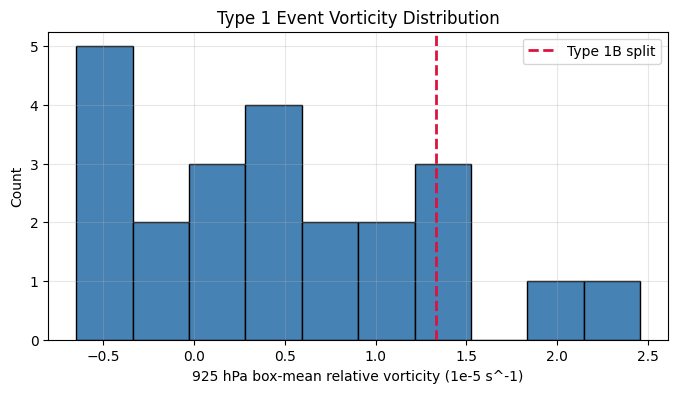

In [60]:
import matplotlib.pyplot as plt

type1_zeta_display = type1_events["zeta_box_mean_s-1"] * 1e5

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(type1_zeta_display, bins=10, color="steelblue", edgecolor="black")
ax.axvline(zeta_split_type1 * 1e5, color="crimson", linestyle="--", linewidth=2, label="Type 1B split")
ax.set_xlabel("925 hPa box-mean relative vorticity (1e-5 s^-1)")
ax.set_ylabel("Count")
ax.set_title("Type 1 Event Vorticity Distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [61]:
final_summary = f"""
JPCZ catalog first-pass ERA5 summary

Baseline validation
- February 2-7, 2018 event detected
- Peak convergence occurs on February 3, 2018

December benchmark
- Shinoda benchmark: 35 events over 19 Decembers
- ERA5 first-pass result: 46 events
- Monthly rate from Shinoda: {35/19:.2f} events per December
- Monthly rate from ERA5 first-pass: {46/19:.2f} events per December

Threshold sensitivity
- mean - 2.0 std: 46 events
- mean - 2.2 std: 39 events
- mean - 2.3 std: 38 events

Final first-pass Shinoda-style classes
- Type 1 strong-monsoon: 23
- Type 2 weak-monsoon: 23
- Type 1A lower-vorticity: 21
- Type 1B higher-vorticity: 2

Interpretation
- The core ERA5 cloud-based detector is functioning.
- Event-count differences are influenced by near-threshold cases.
- The remaining subtype mismatch is concentrated in the higher-vorticity classification.
"""

print(final_summary)



JPCZ catalog first-pass ERA5 summary

Baseline validation
- February 2-7, 2018 event detected
- Peak convergence occurs on February 3, 2018

December benchmark
- Shinoda benchmark: 35 events over 19 Decembers
- ERA5 first-pass result: 46 events
- Monthly rate from Shinoda: 1.84 events per December
- Monthly rate from ERA5 first-pass: 2.42 events per December

Threshold sensitivity
- mean - 2.0 std: 46 events
- mean - 2.2 std: 39 events
- mean - 2.3 std: 38 events

Final first-pass Shinoda-style classes
- Type 1 strong-monsoon: 23
- Type 2 weak-monsoon: 23
- Type 1A lower-vorticity: 21
- Type 1B higher-vorticity: 2

Interpretation
- The core ERA5 cloud-based detector is functioning.
- Event-count differences are influenced by near-threshold cases.
- The remaining subtype mismatch is concentrated in the higher-vorticity classification.



In [62]:
from pathlib import Path

out_path = Path.cwd() / "outputs" / "verification" / "final_first_pass_summary.md"
out_path.write_text(final_summary)

print(f"Saved final first-pass summary to: {out_path}")


Saved final first-pass summary to: /content/JPCZcatalog/outputs/verification/final_first_pass_summary.md
